# CMI on a 1D ring ($S^1$) of N=12 bits — classical analogue of dephased toric code
================================================================================

Following Sang & Hsieh (arXiv:2404.07251):

## The Model (1D repetition code under bit-flip noise):
----------------------------------------------------
- N=12 EDGES on a ring $S^1$, each flipped independently with prob p.\\
(This is the "noise" — like Z-dephasing on qubits in the 2D toric code.)

- STABILIZERS: \\
$S_i = Z_i Z_{i+1}$ for each pair of adjacent qubits.
A flipped edge $e_i$ violates stabilizers $S_{i-1}$ and $S_i$.

- ANYONS / EXCITATIONS / DOMAIN WALLS:\\
  $m_i = e_{i-1} ⊕ e_i$   (boundary operator: $m = ∂e$)
  $m_i = 1$ ↔ stabilizer $S_i$ is violated ↔ "anyon at site $i$".
  These are the EXCITATIONS created by the noise.

## WHERE ANYONS ENTER THE CMI:
---------------------------
  Sang-Hsieh Proposition (notes Prop. 4.1, paper Eq. 5):
\begin{equation}
    S(\rho_{p,Q}) = S(\rho_{0,Q}) + H(m_Q)
\end{equation}

  where $S$ is von Neumann entropy and $H$ is Shannon entropy of the anyon
  distribution $Pr(m_Q)$ on region $Q$.

  In $CMI = S(AB) + S(BC) - S(B) - S(ABC)$, the pure-state parts $S(\rho_{0,Q})$
  CANCEL (they are area-law terms that depend only on boundary of $Q$).

  Therefore:  QUANTUM CMI of $\rho_p$  =  CLASSICAL CMI of $Pr(m)$.

  So computing Shannon-entropy CMI of the anyon distribution is computing
  the quantum CMI of the dephased code state. The anyons are not decoration —
  they are the degrees of freedom whose correlations CMI measures.

## KEY POINT: edges are i.i.d., but ANYONS ARE NOT INDEPENDENT.
  - Adjacent anyons $m_i, m_{i+1}$ share edge $e_i$ → they are correlated.
  - Global constraint: $\sum_i m_i = 0 (\mod 2)$ — the Z₂ homology of S¹.
  - The joint distribution $Pr(m)$ is a correlated distribution = 1D RBIM.

Partition:
  A = {1,2,3,4}, B = {5,6} ∪ {11,12}, C = {7,8,9,10}

In [1]:
import numpy as np
from itertools import product
from collections import defaultdict
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

In [2]:
#Region specification

N = 12

# Regions (0-indexed; user labels 1–12)
A = [0, 1, 2, 3]       # sites 1,2,3,4
B = [4, 5, 10, 11]     # sites 5,6,11,12
C = [6, 7, 8, 9]       # sites 7,8,9,10

assert sorted(A + B + C) == list(range(N))

Defining key functions

In [3]:
def compute_anyon_distribution(p, N=12):
    """
    Compute Pr(m_0, ..., m_{N-1}) over anyon configurations on a ring.
    Edges are i.i.d. Bernoulli(p). Anyon m_i = e_{(i-1)%N} ⊕ e_i.
    
    Returns: dict { anyon_config_tuple : probability }
    """
    prob = defaultdict(float)
    for edge_config in product([0, 1], repeat=N):
        e = np.array(edge_config)
        num_flipped = int(np.sum(e))
        p_config = (p ** num_flipped) * ((1 - p) ** (N - num_flipped))
        m = tuple(int(e[(i - 1) % N] ^ e[i]) for i in range(N))
        prob[m] += p_config
    return dict(prob)


def marginal_distribution(joint_prob, sites):
    """Marginalize joint distribution to a subset of sites."""
    marginal = defaultdict(float)
    for config, p_val in joint_prob.items():
        marginal_config = tuple(config[s] for s in sites)
        marginal[marginal_config] += p_val
    return dict(marginal)


def shannon_entropy(prob_dict):
    """Shannon entropy H = -∑ p log₂ p  (in bits)."""
    H = 0.0
    for p_val in prob_dict.values():
        if p_val > 1e-15:
            H -= p_val * np.log2(p_val)
    return H


def compute_cmi(joint_prob, A, B, C):
    """I(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC)."""
    AB  = sorted(A + B)
    BC  = sorted(B + C)
    ABC = sorted(A + B + C)
    S_AB  = shannon_entropy(marginal_distribution(joint_prob, AB))
    S_BC  = shannon_entropy(marginal_distribution(joint_prob, BC))
    S_B   = shannon_entropy(marginal_distribution(joint_prob, B))
    S_ABC = shannon_entropy(marginal_distribution(joint_prob, ABC))
    return S_AB + S_BC - S_B - S_ABC

#=====================================================================================================
#The correlation function part is extra (?). 
#To check whether there is indeed a correlation between different anyons, 
#and that we are not doing anything wrong (?)

def compute_correlations(joint_prob, N=12):
    """
    Compute the connected correlation function:
      C(d) = <m_0 m_d> - <m_0><m_d>
    This is NONZERO because anyons are coupled through m = ∂e,
    even though the edges are i.i.d.
    """
    # <m_i>
    mean_m = np.zeros(N)
    for config, p_val in joint_prob.items():
        for i in range(N):
            mean_m[i] += config[i] * p_val
    
    # <m_0 m_d> for d = 0, ..., N-1
    corr = np.zeros(N)
    for config, p_val in joint_prob.items():
        for d in range(N):
            corr[d] += config[0] * config[d] * p_val
    
    # Connected: C(d) = <m_0 m_d> - <m_0><m_d>
    connected = corr - mean_m[0] * mean_m
    return connected

Computing CMI and Mutual information of A and C

In [6]:
p_values = np.linspace(0.001, 0.999, 100)
cmi_values = []
mi_AC_values = []

for p in p_values:
    joint = compute_anyon_distribution(p, N)
    cmi_values.append(compute_cmi(joint, A, B, C))
    S_A  = shannon_entropy(marginal_distribution(joint, A))
    S_C  = shannon_entropy(marginal_distribution(joint, C))
    S_AC = shannon_entropy(marginal_distribution(joint, sorted(A + C)))
    mi_AC_values.append(S_A + S_C - S_AC)

cmi_values  = np.array(cmi_values)
mi_AC_values = np.array(mi_AC_values)

print(f"\n{'p':>8s}  {'I(A:C|B)':>12s}  {'I(A:C)':>12s}")
print("-" * 40)
for i in range(0, len(p_values), 10):
    print(f"{p_values[i]:8.4f}  {cmi_values[i]:12.6f}  {mi_AC_values[i]:12.6f}")


       p      I(A:C|B)        I(A:C)
----------------------------------------
  0.0010      0.000068      0.000000
  0.1018      0.274432     -0.000000
  0.2026      0.693595      0.000000
  0.3034      0.938981     -0.000000
  0.4042      0.997912     -0.000000
  0.5050      1.000000      0.000000
  0.6058      0.996542      0.000000
  0.7067      0.924668     -0.000000
  0.8075      0.656665      0.000000
  0.9083      0.232866     -0.000000


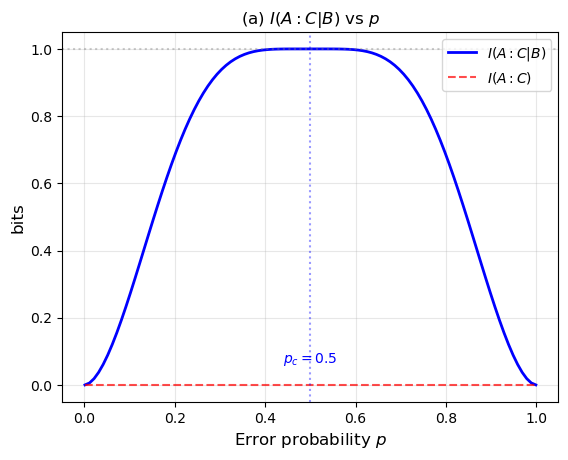

In [8]:
#Plot: CMI vs p 

fig, ax = plt.subplots()

ax.plot(p_values, cmi_values, 'b-', lw=2, label=r'$I(A{:}C|B)$')
ax.plot(p_values, mi_AC_values, 'r--', lw=1.5, alpha=0.7, label=r'$I(A{:}C)$')
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axvline(0.5, color='blue', ls=':', alpha=0.4)
ax.set_xlabel(r'Error probability $p$', fontsize=12)
ax.set_ylabel('bits', fontsize=12)
ax.set_title(r'(a) $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(r'$p_c = 0.5$', xy=(0.5, 0.05), fontsize=10, color='blue',
            ha='center', va='bottom')

plt.show()